<a href="https://colab.research.google.com/github/wenh08/Python_projects-/blob/main/Python_Salaries_datset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [133]:
df = pd.read_csv("https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/Salaries.csv")

In [134]:
df.head()

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


In [135]:
df.describe()

,Unnamed: 0,yrs.since.phd,yrs.service,salary
count,397.000000,397.000000,397.000000,397.000000
mean,199.000000,22.314861,17.614610,113706.458438
std,114.748275,12.887003,13.006024,30289.038695
min,1.000000,1.000000,0.000000,57800.000000
25%,100.000000,12.000000,7.000000,91000.000000
50%,199.000000,21.000000,16.000000,107300.000000
75%,298.000000,32.000000,27.000000,134185.000000
max,397.000000,56.000000,60.000000,231545.000000


In [136]:
#data exploration - mean/median of all salaries, median salary by
#gender and/or rank/title, etc.

df['salary'].mean()




np.float64(113706.45843828715)

In [137]:
df['salary'].median()

107300.0

In [138]:
# The question asks to group the salary by gender/rank
#group the rows by sex, look at the salary, calculate the median for each group

df.groupby('sex')['salary'].median()

# here we see that the middle salary for female is 103,750 while the middle salary for males is 108,43



,salary
sex,
Female,103750.0
Male,108043.0


In [139]:
df.groupby('rank')['salary'].median()
# Here we see that median salary for associate professor is 95,626.5
# While the median salary for assistant professor is 79,800.0
# and of course the higest salary is for professor at 123,321.5



,salary
rank,
AssocProf,95626.5
AsstProf,79800.0
Prof,123321.5


In [140]:
# now to find the median salary by both gender and rank
# group everyone by their rank, and caculate the median salary within each rank
#df.groupby(['GROUP BY THESE'])['CALCULATE THIS'].median()

df.groupby(['sex','rank'])['salary'].median()

#Here we see that a female assoc professor makes 90556.5, while a male assoc professor makes 95626.5 which is 5.6% more than a female

sex     rank     
Female  AssocProf     90556.5
        AsstProf      77000.0
        Prof         120257.5
Male    AssocProf     95626.5
        AsstProf      80182.0
        Prof         123996.0
Name: salary, dtype: float64

In [141]:
df.isnull().sum()
# isnull() checks every value to see if it's missing
#.sum() counts every missing values in each column.
# here we can see that there are no null values. We also see in the count there's no null values as well


,0
Unnamed: 0,0
rank,0
discipline,0
yrs.since.phd,0
yrs.service,0
sex,0
salary,0


In [142]:
df.count()

,0
Unnamed: 0,397
rank,397
discipline,397
yrs.since.phd,397
yrs.service,397
sex,397
salary,397


In [143]:
df['Unnamed: 0'].tail(10)

,Unnamed: 0
387,388
388,389
389,390
390,391
391,392
392,393
393,394
394,395
395,396
396,397


In [144]:
df.shape

(397, 7)

In [145]:
# This column Unnamed: 0 repersents the index for each row, and does not need to be apart of the dataset so i am droping it because it's just an add on starting at 1 rather than 0

df['Unnamed: 0'].nunique()



397

In [146]:
df.drop(columns =['Unnamed: 0'], inplace=True)

In [147]:
df.columns

Index(['rank', 'discipline', 'yrs.since.phd', 'yrs.service', 'sex', 'salary'], dtype='object')

In [148]:
df.rename(columns = {'yrs.service':'service_years',
'yrs.since.phd': 'years_since_phd'
},
inplace=True)

In [149]:
df.columns

Index(['rank', 'discipline', 'years_since_phd', 'service_years', 'sex',
       'salary'],
      dtype='object')

In [150]:
# subetting the dataset to create a new dataframe of only these selected columns

salary_subset = df[['years_since_phd', 'sex', 'service_years', 'salary', 'rank']]
salary_subset

,years_since_phd,sex,service_years,salary,rank
0,19,Male,18,139750,Prof
1,20,Male,16,173200,Prof
2,4,Male,3,79750,AsstProf
3,45,Male,39,115000,Prof
4,40,Male,41,141500,Prof
...,...,...,...,...,...
392,33,Male,30,103106,Prof
393,31,Male,19,150564,Prof
394,42,Male,25,101738,Prof
395,25,Male,15,95329,Prof


In [151]:
#1 what is the average salary overall?
# answer: $113,706

round(salary_subset['salary'].mean())





113706

In [153]:
# 2 Does salary differ by sex?
# yes by 5.7%

round(salary_subset.groupby(['sex'])['salary'].mean())

,salary
sex,
Female,101002.0
Male,115090.0


In [154]:
#Does salary differ depending on years of service?

salary_subset.groupby(['service_years'])['salary'].median()

,salary
service_years,
0,84000.0
1,74856.0
2,84240.0
3,79125.0
4,92000.0
5,94129.5
6,97000.0
7,107154.0
8,95152.0


In [93]:
# want to check for outlier

salary_subset['service_years'].value_counts().sort_index()

,count
service_years,
0,11
1,13
2,15
3,22
4,13
5,8
6,11
7,18
8,18


In [106]:
#For professor the same rank, do males and females earn similar salaries?

salary_subset.groupby(['rank', 'sex',])['salary'].median()



rank       sex   
AssocProf  Female     90556.5
           Male       95626.5
AsstProf   Female     77000.0
           Male       80182.0
Prof       Female    120257.5
           Male      123996.0
Name: salary, dtype: float64

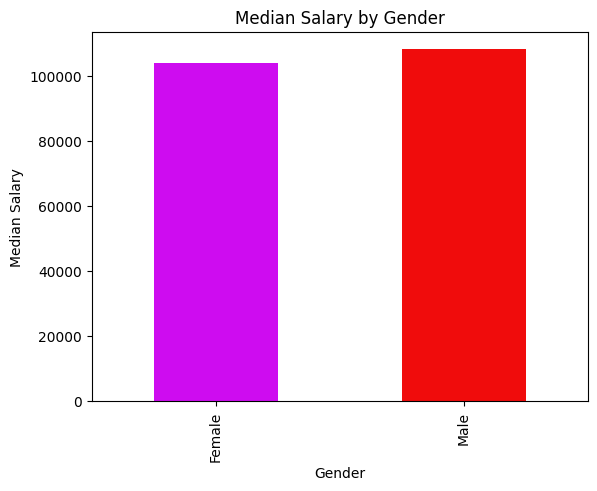

In [112]:
salary_subset.groupby(['sex'])['salary'].median().plot( kind ='bar', color =  ['#ce0cf0','#f00c0c'])
plt.title('Median Salary by Gender')
plt.xlabel('Gender')
plt.ylabel('Median Salary')
plt.show()





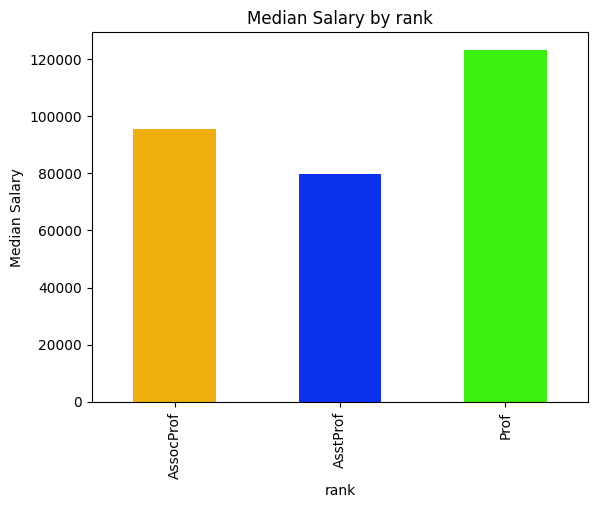

In [117]:
salary_subset.groupby(['rank'])['salary'].median().plot( kind ='bar', color =  ['#f0af0c','#0c32f0','#3af00c'])
plt.title('Median Salary by rank')
plt.xlabel('rank')
plt.ylabel('Median Salary')
plt.show()


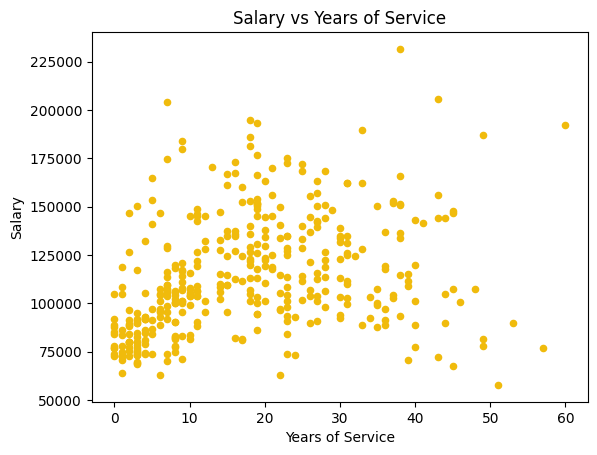

In [131]:
salary_subset.plot(
    kind='scatter',
    x='service_years',
    y='salary',
    color = ['#f0bb0c']
)

plt.title('Salary vs Years of Service')
plt.xlabel('Years of Service')
plt.ylabel('Salary')
plt.show()



In [ ]:
#conclusions - what did you discover?

# I discovered that salary varies based on several factors.
#Male professors had a slightly higher overall median salary than female professors.
# Salary also differed by professor rank, with higher ranking professors generally earning higher salaries.
#When comparing salary with years of service, I found that salary generally increased with experience, especially during the earlier years of service.
# However, the scatter plot showed that professors with similar years of service could have very different salaries, meaning that years of service alone does not determine salary.